In [28]:
import pandas as pd

df_evaluations=pd.read_json("evaluations_results_pipeline-QG.json")
print(df_evaluations.shape)
# print("réponses vides;")
# display(df_evaluations[df_evaluations["Score_claude-sonnet-4.6"]==1])

df_evaluations["claude_gap_score"]=df_evaluations["score_A (réf.)_claude-sonnet-4.6"]-df_evaluations["score_B (RAG)_claude-sonnet-4.6"]
df_evaluations["claude_ratio_score"]=round(df_evaluations["score_B (RAG)_claude-sonnet-4.6"]/df_evaluations["score_A (réf.)_claude-sonnet-4.6"], 2)
df_evaluations["claude_variation_score"]=round((df_evaluations["score_B (RAG)_claude-sonnet-4.6"]-df_evaluations["score_A (réf.)_claude-sonnet-4.6"])/df_evaluations["score_A (réf.)_claude-sonnet-4.6"], 2)

df_evaluations["gemini_gap_score"]=df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"]-df_evaluations["score_B (RAG)_gemini-3.1-pro-preview"]
df_evaluations["gemini_ratio_score"]=round(df_evaluations["score_B (RAG)_gemini-3.1-pro-preview"]/df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"], 2)
df_evaluations["gemini_variation_score"]=round((df_evaluations["score_B (RAG)_gemini-3.1-pro-preview"]-df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"])/df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"], 2)

df_evaluations["gpt_gap_score"]=df_evaluations["score_A (réf.)_gpt-5.2"]-df_evaluations["score_B (RAG)_gpt-5.2"]
df_evaluations["gpt_ratio_score"]=round(df_evaluations["score_B (RAG)_gpt-5.2"]/df_evaluations["score_A (réf.)_gpt-5.2"], 2)
df_evaluations["gpt_variation_score"]=round((df_evaluations["score_B (RAG)_gpt-5.2"]-df_evaluations["score_A (réf.)_gpt-5.2"])/df_evaluations["score_A (réf.)_gpt-5.2"], 2)



df_evaluations["gemini-flash_ratio_score"]=round(df_evaluations["score_B (RAG)_gemini-3-flash-preview"]/df_evaluations["score_A (réf.)_gemini-3-flash-preview"], 2)
df_evaluations["gpt-mini_ratio_score"]=round(df_evaluations["score_B (RAG)_gpt-5-mini"]/df_evaluations["score_A (réf.)_gpt-5-mini"], 2)


display(df_evaluations.drop(columns=[
    "corpus", "question", "question_level", "date",
    "reponse_reference", "response",
    "custom_evaluation_text_claude-sonnet-4.6", "custom_evaluation_text_gpt-5.2", "custom_evaluation_text_gpt-5-mini", "custom_evaluation_text_gemini-3-flash-preview",
    # "custom_evaluation_text_gemini-3.1-pro-preview"
    'score_A (réf.)_claude-sonnet-4.6', 'score_B (RAG)_claude-sonnet-4.6', 
    # 'score_A (réf.)_gemini-3.1-pro-preview', 'score_B (RAG)_gemini-3.1-pro-preview', 
     'score_A (réf.)_gemini-3-flash-preview', 'score_B (RAG)_gemini-3-flash-preview', 
     'score_A (réf.)_gpt-5.2', 'score_B (RAG)_gpt-5.2', 
    'score_A (réf.)_gpt-5-mini', 'score_B (RAG)_gpt-5-mini',    
    "claude_ratio_score", "claude_gap_score", "gemini_gap_score", "gpt_gap_score", "claude_variation_score", "gemini_variation_score", "gpt_variation_score"
]))

print("\n===Gap scores group by model et rag type:===\n")
# for s in ["gemini_gap_score", "gpt_gap_score"]:    
for s in ["gemini_ratio_score", "gpt_ratio_score", "gpt-mini_ratio_score"]:    
    print(s)
    display(df_evaluations.groupby(["model", 'rag_type'])[s].mean().reset_index())



(20, 24)


,question_label,rag_type,model,score_A (réf.)_gemini-3.1-pro-preview,score_B (RAG)_gemini-3.1-pro-preview,custom_evaluation_text_gemini-3.1-pro-preview,gemini_ratio_score,gpt_ratio_score,gemini-flash_ratio_score,gpt-mini_ratio_score
0,question_cadre,hybrid,DeepSeek-V3.2:novita,6.0,9.0,{'verdict': 'La réponse B est la meilleure car...,1.50,1.17,0.89,1.12
1,positions_interlocuteurs,hybrid,DeepSeek-V3.2:novita,5.0,8.0,{'verdict': 'La Réponse B est nettement supéri...,1.60,0.86,0.89,0.88
2,distinction entre faits et opinions,hybrid,DeepSeek-V3.2:novita,8.0,9.0,{'verdict': 'Les deux réponses répondent parfa...,1.12,1.50,0.78,1.29
3,verifiabilite_precision_retriever,hybrid,DeepSeek-V3.2:novita,6.0,9.0,{'verdict': 'La réponse B est la meilleure car...,1.50,1.60,0.78,0.67
4,question_cadre,hybrid_hyde,DeepSeek-V3.2:novita,6.0,9.0,{'verdict': 'La réponse B est nettement supéri...,1.50,1.50,1.29,0.89
5,positions_interlocuteurs,hybrid_hyde,DeepSeek-V3.2:novita,6.0,8.0,{'verdict': 'La réponse B est meilleure car el...,1.33,1.17,0.78,0.89
6,distinction entre faits et opinions,hybrid_hyde,DeepSeek-V3.2:novita,8.0,9.0,{'verdict': 'Les deux réponses proposent une e...,1.12,1.33,0.89,1.50
7,verifiabilite_precision_retriever,hybrid_hyde,DeepSeek-V3.2:novita,NaN,NaN,NaN,NaN,1.80,0.78,1.50
8,question_cadre,graph,gpt-oss-120b:novita,7.0,3.0,{'verdict': 'La réponse A est nettement supéri...,0.43,0.38,0.56,0.56
9,positions_interlocuteurs,graph,gpt-oss-120b:novita,7.0,3.0,{'verdict': 'La réponse A est nettement supéri...,0.43,0.57,0.56,0.56



===Gap scores group by model et rag type:===

gemini_ratio_score


,model,rag_type,gemini_ratio_score
0,DeepSeek-V3.2:novita,hybrid,1.430000
1,DeepSeek-V3.2:novita,hybrid_hyde,1.316667
2,gpt-oss-120b:novita,graph,0.480000
3,gpt-oss-120b:novita,hybrid,1.480000
4,gpt-oss-120b:novita,hybrid_hyde,1.105000


gpt_ratio_score


,model,rag_type,gpt_ratio_score
0,DeepSeek-V3.2:novita,hybrid,1.2825
1,DeepSeek-V3.2:novita,hybrid_hyde,1.4500
2,gpt-oss-120b:novita,graph,0.6000
3,gpt-oss-120b:novita,hybrid,1.0225
4,gpt-oss-120b:novita,hybrid_hyde,1.0175


gpt-mini_ratio_score


,model,rag_type,gpt-mini_ratio_score
0,DeepSeek-V3.2:novita,hybrid,0.9900
1,DeepSeek-V3.2:novita,hybrid_hyde,1.1950
2,gpt-oss-120b:novita,graph,0.6625
3,gpt-oss-120b:novita,hybrid,1.0600
4,gpt-oss-120b:novita,hybrid_hyde,1.1450


In [ ]:
text={'verdict': "La réponse RAG est solide, bien structurée et lisible en autonomie sans accès au corpus. Elle couvre correctement les quatre parties demandées et inclut des données chiffrées bien attribuées. Cependant, elle présente un manque critique en partie 4 (omission du désaccord sur la répartition des sacrifices), des citations parfois moins précises que la référence pour la première tension (retraites), et oublie quelques chiffres-clés et l'idée du rejet des 'solutions magiques'.", 'exactitude': "bon — Les faits et chiffres cités sont globalement exacts et bien attribués ; seule la description du '50 milliards' est légèrement imprécise (attribuée à 'la réforme de 1982' plutôt qu'au coût des 2,7 millions de retraités de moins de 65 ans).", 'couverture': "moyen — Un manque critique en partie 4 : le désaccord Dufourcq/Aghion sur la répartition des sacrifices (effort partagé vs ciblage des seules dépenses sociales) est absent ; en partie 1, l'idée du rejet des 'solutions magiques' (annulation de dette, taxe Zucman) manque également.", 'lisibilite': 'bon — Le texte est clair, hiérarchisé et compréhensible pour tout lecteur sans accès au corpus ; le vocabulaire est explicité et les exemples sont contextualisés.', 'organisation': 'bon — Progression logique entre les quatre parties, usage efficace du gras pour les concepts clés, transitions fluides entre les intervenants.', 'structure_formelle': "bon — Les quatre parties demandées sont strictement respectées, avec une section 'Sources' ajoutée en complément, sans que cela nuise à la structure globale.", 'ecarts': {'manques_critiques': ["Partie 4 : absence du troisième désaccord central entre Dufourcq (ciblage des dépenses sociales) et Aghion (effort partagé incluant entreprises et plus riches), avec les citations spécifiques (ex: Aghion : 'On ne peut pas demander de l'effort aux retraités si... on ne touche absolument pas aux crédits impôt-recherche ou aux holdings patrimoniales').", "Partie 4, premier désaccord : absence de la citation forte de Dufourcq sur la suspension de la réforme des retraites ('un énorme recul... sacrilège') et de la citation tactique d'Aghion ('on a suspendu l'horloge... le coût d'une instabilité politique aurait été supérieur')."], 'manques_editoriaux': ["Chiffre du 'reste à charge' en santé (5%, le plus faible du monde) mentionné par Dufourcq.", 'Chiffre de 10% des prestations sociales financées par la dette.', "Partie 1 : idée du rejet des 'solutions magiques' (annulation de dette BCE, taxe Zucman) absente."], 'erreurs': [], 'ajouts_utiles': ["Troisième point de désaccord sur le 'ton et le diagnostic' (Aghion se défend d'être néolibéral, Dufourcq assume un discours catastrophiste) : ajout cohérent avec le corpus et enrichissant, bien qu'absent de la référence.", "Mention du rôle de Finkielkraut comme 'animateur-questionneur' au lieu de simple modérateur, ce qui précise sa contribution."], 'ajouts_risques': []}, 'recommandations': ["Ajouter en partie 4 le désaccord sur la répartition des sacrifices, en citant explicitement Aghion sur le partage de l'effort (crédits impôt-recherche, holdings) et Dufourcq sur la priorité aux coupes dans les dépenses sociales.", "Renforcer les citations en partie 4, premier point : inclure la formule 'sacrilège' de Dufourcq et la formule '63 ans et revoyure' / 'suspension de l'horloge' d'Aghion pour mieux illustrer la tension.", "Compléter la partie 1 avec l'idée du rejet des alternatives 'magiques' (annulation de dette, taxe Zucman), et la partie 2 avec les chiffres du reste à charge (5%) et des 10% de prestations financées par la dette."]}
display(text)

{'verdict': "La réponse RAG est solide, bien structurée et lisible en autonomie sans accès au corpus. Elle couvre correctement les quatre parties demandées et inclut des données chiffrées bien attribuées. Cependant, elle présente un manque critique en partie 4 (omission du désaccord sur la répartition des sacrifices), des citations parfois moins précises que la référence pour la première tension (retraites), et oublie quelques chiffres-clés et l'idée du rejet des 'solutions magiques'.",
 'exactitude': "bon — Les faits et chiffres cités sont globalement exacts et bien attribués ; seule la description du '50 milliards' est légèrement imprécise (attribuée à 'la réforme de 1982' plutôt qu'au coût des 2,7 millions de retraités de moins de 65 ans).",
 'couverture': "moyen — Un manque critique en partie 4 : le désaccord Dufourcq/Aghion sur la répartition des sacrifices (effort partagé vs ciblage des seules dépenses sociales) est absent ; en partie 1, l'idée du rejet des 'solutions magiques' (

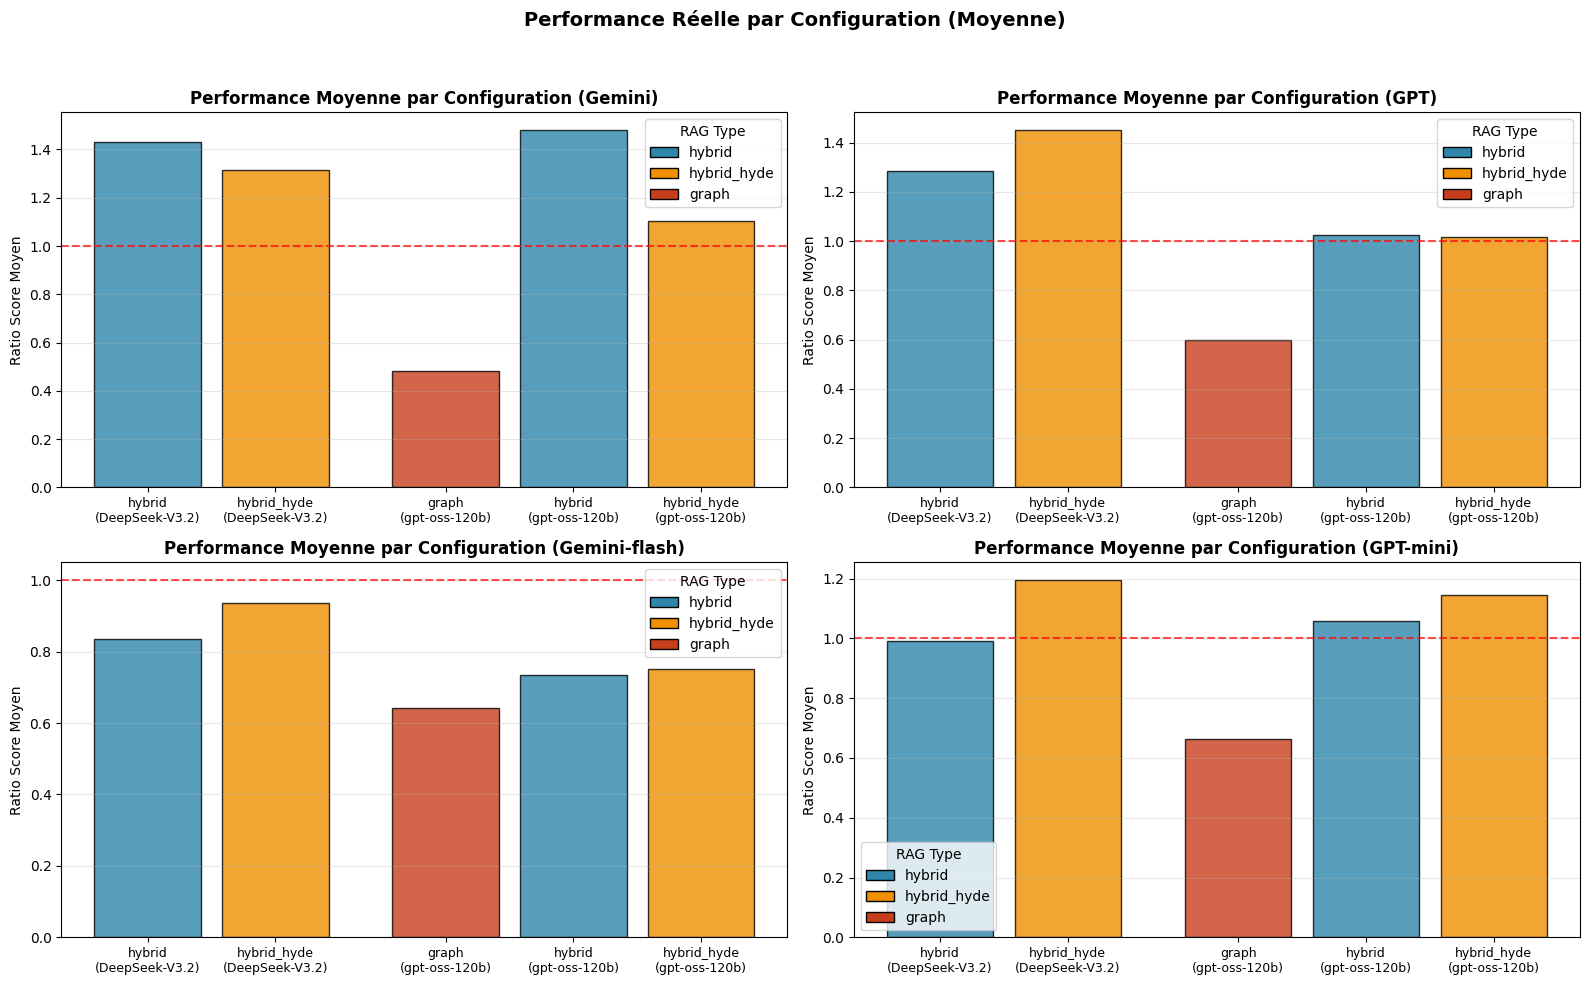

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_viz = df_evaluations.copy()
df_viz['model_short'] = df_viz['model'].str.split(':').str[0]

# Calcul des moyennes
agg_gemini = df_viz.groupby(['model_short', 'rag_type'])['gemini_ratio_score'].mean().reset_index()
agg_gemini_flash = df_viz.groupby(['model_short', 'rag_type'])['gemini-flash_ratio_score'].mean().reset_index()
agg_gpt = df_viz.groupby(['model_short', 'rag_type'])['gpt_ratio_score'].mean().reset_index()
agg_gpt_mini = df_viz.groupby(['model_short', 'rag_type'])['gpt-mini_ratio_score'].mean().reset_index()

# Correction 1: figsize plus grand pour 4 graphiques
# Correction 2: flatten() pour accéder aux axes en 1D
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

models = df_viz['model_short'].unique()
colors = {'hybrid': '#2E86AB', 'hybrid_hyde': '#F18F01', 'graph': '#C73E1D'}

for ax, data, title in [
    (axes[0], agg_gemini, 'Gemini'), 
    (axes[1], agg_gpt, 'GPT'),
    (axes[2], agg_gemini_flash, 'Gemini-flash'), 
    (axes[3], agg_gpt_mini, 'GPT-mini')                                                 
]:
    
    x_pos = 0
    width = 0.25
    positions = []
    labels = []
    
    for model in models:
        subset = data[data['model_short'] == model]
        for _, row in subset.iterrows():
            positions.append(x_pos)
            labels.append(f"{row['rag_type']}\n({row['model_short']})")
            ax.bar(x_pos, row.iloc[2], width, 
                   color=colors[row['rag_type']], 
                   edgecolor='black', alpha=0.8)
            x_pos += width + 0.05
        
        x_pos += 0.1
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Ratio Score Moyen', fontsize=10)
    ax.set_title(f'Performance Moyenne par Configuration ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[r], edgecolor='black', label=r) 
                       for r in ['hybrid', 'hybrid_hyde', 'graph']]
    ax.legend(handles=legend_elements, title='RAG Type')

plt.suptitle('Performance Réelle par Configuration (Moyenne)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

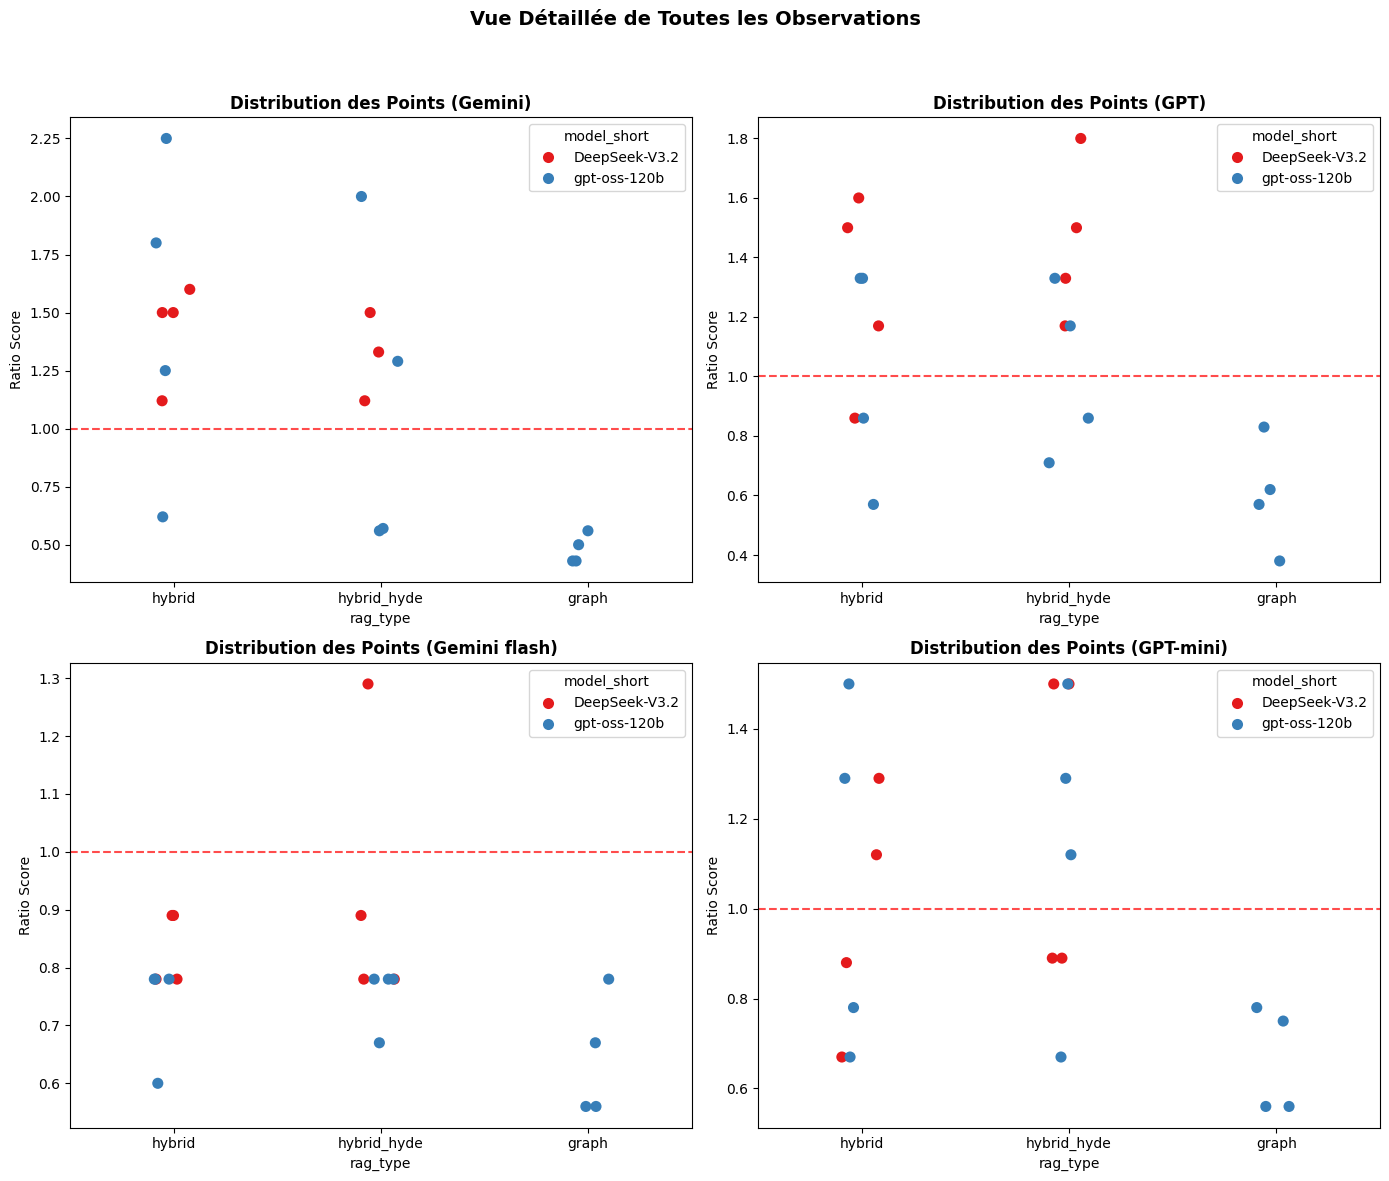

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Correction : convertir en tableau 1D

# Stripplot pour voir tous les points individuels
sns.stripplot(data=df_viz, x='rag_type', y='gemini_ratio_score', 
              hue='model_short', ax=axes[0], size=8, palette='Set1')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Distribution des Points (Gemini)', fontweight='bold')
axes[0].set_ylabel('Ratio Score')

sns.stripplot(data=df_viz, x='rag_type', y='gpt_ratio_score', 
              hue='model_short', ax=axes[1], size=8, palette='Set1')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Distribution des Points (GPT)', fontweight='bold')
axes[1].set_ylabel('Ratio Score')

# Stripplot pour voir tous les points individuels
sns.stripplot(data=df_viz, x='rag_type', y='gemini-flash_ratio_score', 
              hue='model_short', ax=axes[2], size=8, palette='Set1')
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Distribution des Points (Gemini flash)', fontweight='bold')
axes[2].set_ylabel('Ratio Score')

# Ajout du 4ème graphique manquant (GPT-mini)
sns.stripplot(data=df_viz, x='rag_type', y='gpt-mini_ratio_score', 
              hue='model_short', ax=axes[3], size=8, palette='Set1')
axes[3].axhline(1.0, color='red', linestyle='--', alpha=0.7)
axes[3].set_title('Distribution des Points (GPT-mini)', fontweight='bold')
axes[3].set_ylabel('Ratio Score')

plt.suptitle('Vue Détaillée de Toutes les Observations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [2]:
df_tokens_usage_graph=pd.read_json("logs/tokens_usage_graph.json")
print(df_tokens_usage_graph.shape)
df_tokens_usage_graph

(187, 11)


,hash_query,rag_type,query,date,input_tokens,completion_tokens,reasoning_tokens,input_price,completion_price,reasoning_price,model
0,4c876d3f4b72bf45d3c57b0bd06f7050,pathrag,\n Peux tu me faire une synthèse de...,2026-03-07 15:00:40.316437,515,73,0,0.00014,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
1,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:25:39.868283,462,64,0,0.00012,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
2,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:26:25.950428,22881,1259,0,0.00618,0.00050,0,deepseek-ai/DeepSeek-V3.2:novita
3,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:27:14.411920,492,70,0,0.00013,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita
4,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:28:08.884586,22678,1626,0,0.00612,0.00065,0,deepseek-ai/DeepSeek-V3.2:novita
...,...,...,...,...,...,...,...,...,...,...,...
182,1ee9f6a9598940f7eacd129a981365cf,pathrag,Quelles sont les mesures environnementales con...,2026-03-17 17:58:59.293744,21952,683,0,0.00088,0.00017,0,openai/gpt-oss-120b:cheapest
183,dc65a6f79367b483898172bf5cf4fd8e,pathrag,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17 17:59:23.029577,492,489,0,0.00002,0.00012,0,openai/gpt-oss-120b:cheapest
184,dc65a6f79367b483898172bf5cf4fd8e,pathrag,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17 17:59:37.396216,20899,413,0,0.00084,0.00010,0,openai/gpt-oss-120b:cheapest
185,26c184375ed9f40088ed1113b5e201a4,pathrag,Quel a été l'impact exact de la suspension de ...,2026-03-17 18:00:11.935576,478,435,0,0.00002,0.00011,0,openai/gpt-oss-120b:cheapest


In [7]:
df_tokens_usage_hybrid=pd.read_json("logs/tokens_usage_hybrid.json")
print(df_tokens_usage_hybrid.shape)

# 1. Mapping des types RAG
rag_type_mapping = {
    'graph': 'pathrag', 
    'hybrid': 'hybrid', 
    'hybrid_hyde': 'hybrid_hyde'
}

records = []
columns_to_process = ['graph', 'hybrid', 'hybrid_hyde']

for col in columns_to_process:
    # Vérifie si la colonne existe dans le dataframe
    if col not in df_tokens_usage_hybrid.columns:
        continue
        
    for idx, cell_data in df_tokens_usage_hybrid[col].items():
        
        if isinstance(cell_data, dict) and cell_data:
            
            for query_hash, details in cell_data.items():
                
                # Extraction sécurisée des sous-dictionnaires de prix
                prices_final = details.get('final_response_price', {})
                prices_reranker = details.get('reranker_price', {})
                prices_hyde = details.get('hyde_tokens_price', {})
                
                # Gestion des tokens (certains JSON ont '_tokens', d'autres non)
                # On essaie la version longue, sinon la version courte
                input_tokens = details.get('final_response_input_tokens') or details.get('final_response_input')
                output_tokens = details.get('final_response_output_tokens') or details.get('final_response_output')
                reasoning_tokens = details.get('final_reasoning_output_tokens') or details.get('final_reasoning_output')
                
                row = {
                    'hash_query': query_hash,
                    'rag_type': rag_type_mapping.get(col, col),
                    'query': details.get('query', '').strip(),
                    'date': details.get('date'),
                    
                    # Tokens Génération Finale
                    'input_tokens': input_tokens,
                    'completion_tokens': output_tokens,
                    'reasoning_tokens': reasoning_tokens,
                    
                    # Prix Génération Finale
                    'input_price_final': prices_final.get('input_price'),
                    'completion_price_final': prices_final.get('completion_price'),
                    'reasoning_price_final': prices_final.get('reasoning_price'),
                    
                    # Prix Reranker (si présent)
                    'input_price_reranker': prices_reranker.get('input_price'),
                    'completion_price_reranker': prices_reranker.get('completion_price'),
                    
                    # Prix Hyde (si présent)
                    'input_price_hyde': prices_hyde.get('input_price'),
                    'completion_price_hyde': prices_hyde.get('completion_price'),
                    
                    'model': details.get('model_generation')
                }
                records.append(row)

# 4. Création du DataFrame
df_flat = pd.DataFrame(records)

# ... (Votre code de création du DataFrame et conversion numérique) ...
# ==============================================================================
# CONVERSION DES COLONNES NUMÉRIQUES
# ==============================================================================
# Liste de toutes les colonnes numériques attendues
numeric_cols = [
    'input_tokens', 'completion_tokens', 'reasoning_tokens',
    'input_price_final', 'completion_price_final', 'reasoning_price_final',
    'input_price_reranker', 'completion_price_reranker',
    'input_price_hyde', 'completion_price_hyde'
]

# On ne convertit que les colonnes qui existent vraiment dans le dataframe
existing_numeric_cols = [c for c in numeric_cols if c in df_flat.columns]
df_flat[existing_numeric_cols] = df_flat[existing_numeric_cols].apply(pd.to_numeric, errors='coerce')


# ==============================================================================
# ÉTAPE 1 : CRÉATION DES TOTAUX (Si absents)
# ==============================================================================
# On s'assure que les colonnes de base existent avant de calculer les totaux
base_price_cols = {
    'total_price_final': ['input_price_final', 'completion_price_final', 'reasoning_price_final'],
    'total_price_hyde': ['input_price_hyde', 'completion_price_hyde'],
    'total_price_reranker': ['input_price_reranker', 'completion_price_reranker']
}

for total_col, sub_cols in base_price_cols.items():
    if total_col not in df_flat.columns:
        # On prend uniquement les sous-colonnes qui existent vraiment
        valid_sub_cols = [c for c in sub_cols if c in df_flat.columns]
        if valid_sub_cols:
            df_flat[total_col] = df_flat[valid_sub_cols].fillna(0).sum(axis=1)
        else:
            df_flat[total_col] = 0.0

# ==============================================================================
# ÉTAPE 2 : HACK - Propagation des données Reranker par hash_query
# ==============================================================================
reranker_cols = ['input_price_reranker', 'completion_price_reranker']

# On vérifie que les colonnes source existent
if all(col in df_flat.columns for col in reranker_cols):
    
    # 1. Récupération de la première valeur non-NaN par hash_query
    reranker_lookup = df_flat.groupby('hash_query')[reranker_cols].first()
    
    # 2. Remplissage des trous (NaN) pour les lignes hybrid_hyde
    for col in reranker_cols:
        df_flat[col] = df_flat[col].fillna(df_flat['hash_query'].map(reranker_lookup[col]))
    
    # 3. Recalcul des totaux avec les nouvelles valeurs remplies
    df_flat['total_price_reranker'] = df_flat['input_price_reranker'].fillna(0) + df_flat['completion_price_reranker'].fillna(0)
    
    # Vérification de sécurité pour total_price_final avant le calcul final
    if 'total_price_final' not in df_flat.columns:
        df_flat['total_price_final'] = 0.0
    if 'total_price_hyde' not in df_flat.columns:
        df_flat['total_price_hyde'] = 0.0
        
    df_flat['total_price'] = (
        df_flat['total_price_final'] + 
        df_flat['total_price_reranker'] + 
        df_flat['total_price_hyde']
    )

# ==============================================================================
# ÉTAPE 3 : NETTOYAGE DES DOUBLONS
# ==============================================================================
df_flat = df_flat.drop_duplicates().reset_index(drop=True)
df_flat.rename(columns={"total_price_final": "generation_answer_price"}, inplace=True)
# Affichage de vérification
(df_flat)

(239, 3)


,hash_query,rag_type,query,date,input_tokens,completion_tokens,reasoning_tokens,input_price_final,completion_price_final,reasoning_price_final,input_price_reranker,completion_price_reranker,input_price_hyde,completion_price_hyde,model,generation_answer_price,total_price_hyde,total_price_reranker,total_price
0,10e27b16b820d8ea5076c7ccd32dd8e9,hybrid,Peux tu me faire une synthèse de ce texte en 4...,2026-03-07T18:44:41.535304,20095.0,1874.0,NaN,0.005426,0.000750,0.0,0.006626,1.507350e-02,NaN,NaN,deepseek-ai/DeepSeek-V3.2:novita,0.006175,0.000000,0.021699,0.027875
1,5fdbc9b1e0d52ffac452e81f439381f4,hybrid,"Pour chaque intervenant, peux-tu résumer son p...",2026-03-07T19:29:07.120220,20223.0,1681.0,NaN,0.005460,0.000672,0.0,0.005534,1.665000e-04,NaN,NaN,deepseek-ai/DeepSeek-V3.2:novita,0.006133,0.000000,0.005700,0.011833
2,87aa24f88e680293a7264af6a67390bf,hybrid,"Dans ce qui est dit, qu’est-ce qui relève plut...",2026-03-07T19:33:00.000759,19621.0,1838.0,NaN,0.005298,0.000735,0.0,0.005818,1.665000e-04,NaN,NaN,deepseek-ai/DeepSeek-V3.2:novita,0.006033,0.000000,0.005984,0.012017
3,ff7ae5b92259b2fe924a0bd6d55983e8,hybrid,Quels sont les arguments les plus importants a...,2026-03-07T19:36:51.190028,20730.0,1936.0,NaN,0.005597,0.000774,0.0,0.005756,1.665000e-04,NaN,NaN,deepseek-ai/DeepSeek-V3.2:novita,0.006372,0.000000,0.005922,0.012294
4,10e27b16b820d8ea5076c7ccd32dd8e9,hybrid,Peux tu me faire une synthèse de ce texte en 4...,2026-03-07T21:31:58.685185,NaN,NaN,NaN,NaN,NaN,NaN,0.006626,1.507350e-02,NaN,NaN,Qwen/Qwen3-235B-A22B-Instruct-2507:cheapest,0.000000,0.000000,0.021699,0.021699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,8414baff26e8e757514f3c4df6bc6b7c,hybrid_hyde,Quels arguments Nicolas Dufourcq avance-t-il d...,2026-03-17T18:29:00.361913,4796.0,1250.0,0.0,0.000192,0.000313,0.0,0.000074,8.000000e-07,0.000161,0.000217,openai/gpt-oss-120b:cheapest,0.000504,0.000378,0.000075,0.000957
276,e9f193fa702cbc0407a221a6248314ed,hybrid_hyde,Pourquoi Philippe Aghion propose-t-il dans ce ...,2026-03-17T18:30:05.730169,3932.0,109.0,0.0,0.000157,0.000027,0.0,0.000222,2.400000e-06,0.000162,0.000174,openai/gpt-oss-120b:cheapest,0.000185,0.000336,0.000224,0.000745
277,08043ddc2002f6159c70e2bd02ee533c,hybrid_hyde,Quelles sont les mesures environnementales con...,2026-03-17T18:30:41.346652,3938.0,182.0,0.0,0.000158,0.000046,0.0,0.000038,4.000000e-07,0.000162,0.000214,openai/gpt-oss-120b:cheapest,0.000203,0.000376,0.000039,0.000618
278,d0ae891539dda015a68580f96732a84d,hybrid_hyde,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17T18:31:28.450864,3923.0,165.0,0.0,0.000157,0.000041,0.0,0.000069,8.000000e-07,0.000168,0.000135,openai/gpt-oss-120b:cheapest,0.000198,0.000303,0.000070,0.000571
